#Scope: Pre-modeling validation for time-series forecasting.
15 components covering feature engineering, leakage detection,
distribution stability, drift, and readiness scoring.

In [1]:
import json
import logging
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
%matplotlib inline

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

In [2]:
DATA_PATH = Path("../data/training/training_dataset.parquet")
FIGURES_DIR = Path("../reports/eda_forecast_ready/figures")
STATS_PATH = Path("../reports/eda_forecast_ready/forecast_readiness_stats.json")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
STATS_PATH.parent.mkdir(parents=True, exist_ok=True)

POLLUTANT_COLS = ["pm25", "pm10", "no2", "so2", "co", "o3"]
WEATHER_COLS   = ["temperature", "feels_like", "humidity", "pressure", "visibility", "wind_speed", "cloudiness"]
TARGET_COL     = "aqi"
TIME_COL       = "timestamp"
CITY_COL       = "city"

FORECAST_HORIZON = 24
SEQUENCE_LENGTH  = 168
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15

fr_stats = {}

In [3]:
df = pd.read_parquet(DATA_PATH)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], utc=True, errors="coerce")

# Ensure numeric
for col in POLLUTANT_COLS + WEATHER_COLS + [TARGET_COL]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Time features
df["year"] = df[TIME_COL].dt.year
df["month"] = df[TIME_COL].dt.month
df["day"] = df[TIME_COL].dt.day
df["hour"] = df[TIME_COL].dt.hour
df["day_of_week"] = df[TIME_COL].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

# Sort chronologically
df = df.sort_values(by=[TIME_COL]).reset_index(drop=True)

numeric_features = [c for c in [TARGET_COL] + POLLUTANT_COLS + WEATHER_COLS if c in df.columns]

print(f"Shape: {df.shape}")
print(f"Range: {df[TIME_COL].min()} to {df[TIME_COL].max()}")
df.head()

Shape: (105054, 32)
Range: 2022-07-21 00:00:00+00:00 to 2026-07-18 23:00:00+00:00


,city,country,latitude,longitude,timestamp,temperature,feels_like,humidity,pressure,visibility,...,source,created_at,hour,day,month,day_of_week,is_weekend,aqi_change_rate,aqi_rolling_mean_3h,year
0,Islamabad,PK,33.6844,73.0479,2022-07-21 00:00:00+00:00,26.6,30.6,83,942,-1,...,"Open-Meteo (historical, CAMS reanalysis)",2026-07-21T11:56:30.908001+00:00,0,21,7,3,0,0.0,0.0,2022
1,Lahore,PK,31.5497,74.3436,2022-07-21 00:00:00+00:00,27.7,33.0,89,972,-1,...,"Open-Meteo (historical, CAMS reanalysis)",2026-07-21T11:55:59.013006+00:00,0,21,7,3,0,0.0,0.0,2022
2,Karachi,PK,24.8607,67.0011,2022-07-21 00:00:00+00:00,28.4,31.6,86,1000,-1,...,"Open-Meteo (historical, CAMS reanalysis)",2026-07-21T11:55:27.741553+00:00,0,21,7,3,0,0.0,0.0,2022
3,Islamabad,PK,33.6844,73.0479,2022-07-21 01:00:00+00:00,26.4,30.6,84,940,-1,...,"Open-Meteo (historical, CAMS reanalysis)",2026-07-21T11:56:30.908001+00:00,1,21,7,3,0,0.0,0.0,2022
4,Lahore,PK,31.5497,74.3436,2022-07-21 01:00:00+00:00,26.6,31.7,93,974,-1,...,"Open-Meteo (historical, CAMS reanalysis)",2026-07-21T11:55:59.013006+00:00,1,21,7,3,0,0.0,0.0,2022


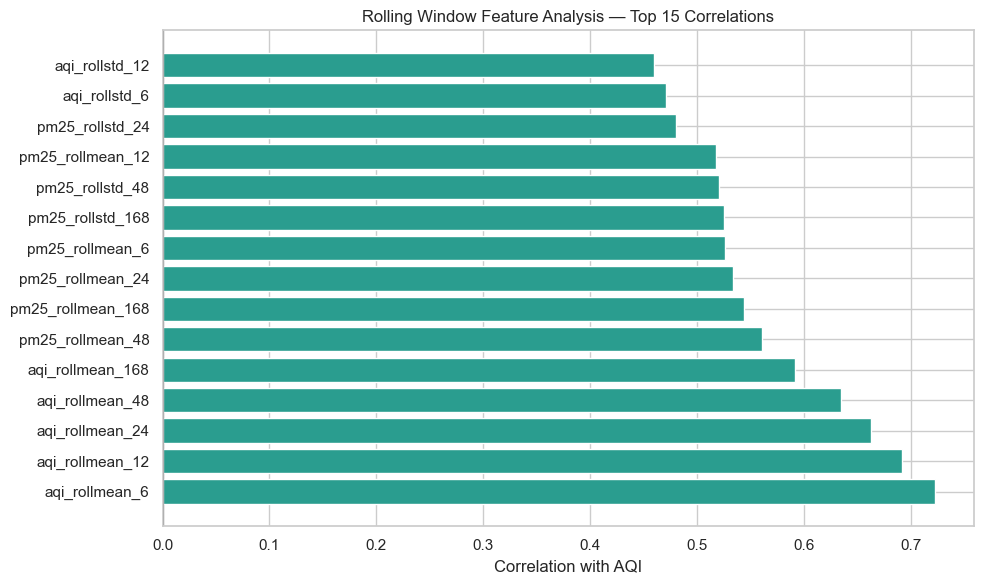

In [5]:
windows = [6, 12, 24, 48, 168]
roll_corr = {}

for col in numeric_features:
    for w in windows:
        for stat, func in [("mean", lambda s: s.rolling(w, min_periods=1).mean()),
                           ("std", lambda s: s.rolling(w, min_periods=1).std())]:
            roll_col = f"{col}_roll{stat}_{w}"
            df[roll_col] = func(df[col])
            corr = df[[TARGET_COL, roll_col]].corr().iloc[0, 1]
            if not pd.isna(corr):
                roll_corr[roll_col] = round(float(corr), 4)

roll_sorted = dict(sorted(roll_corr.items(), key=lambda x: abs(x[1]), reverse=True))
fr_stats["rolling_window_analysis"] = {
    "total_created": len(roll_corr),
    "top_15": dict(list(roll_sorted.items())[:15]),
}

fig, ax = plt.subplots(figsize=(10, 6))
top = list(roll_sorted.items())[:15]
colors = ["#2a9d8f" if v > 0 else "#d1495b" for _, v in top]
ax.barh([k for k, _ in top], [v for _, v in top], color=colors)
ax.set_xlabel("Correlation with AQI")
ax.set_title("Rolling Window Feature Analysis — Top 15 Correlations")
ax.axvline(x=0, color="black", linewidth=0.8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "rolling_window_analysis.png", dpi=110, bbox_inches="tight")
plt.show()

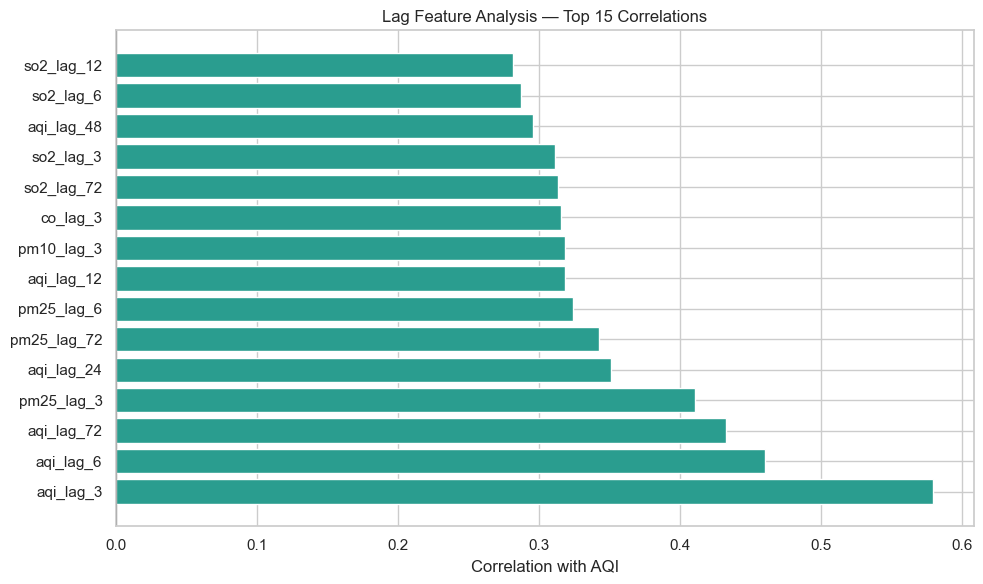

In [6]:
lags = [1, 3, 6, 12, 24, 48, 72]
lag_corr = {}

for col in numeric_features:
    for lag in lags:
        lag_col = f"{col}_lag_{lag}"
        df[lag_col] = df[col].shift(lag)
        corr = df[[TARGET_COL, lag_col]].corr().iloc[0, 1]
        if not pd.isna(corr):
            lag_corr[lag_col] = round(float(corr), 4)

lag_sorted = dict(sorted(lag_corr.items(), key=lambda x: abs(x[1]), reverse=True))
fr_stats["lag_feature_analysis"] = {
    "total_created": len(lag_corr),
    "top_15": dict(list(lag_sorted.items())[:15]),
}

fig, ax = plt.subplots(figsize=(10, 6))
top = list(lag_sorted.items())[:15]
colors = ["#2a9d8f" if v > 0 else "#d1495b" for _, v in top]
ax.barh([k for k, _ in top], [v for _, v in top], color=colors)
ax.set_xlabel("Correlation with AQI")
ax.set_title("Lag Feature Analysis — Top 15 Correlations")
ax.axvline(x=0, color="black", linewidth=0.8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "lag_feature_analysis.png", dpi=110, bbox_inches="tight")
plt.show()

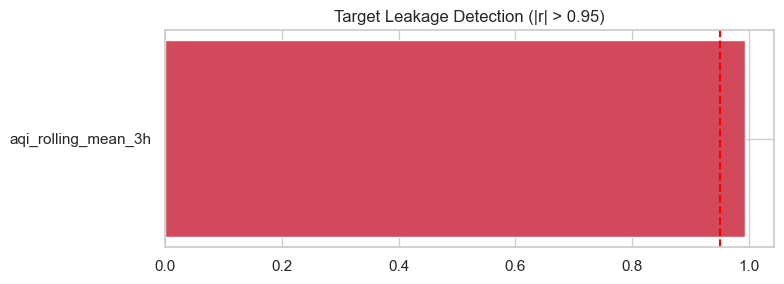

In [7]:
# Features with suspiciously high correlation (potential leakage)
feature_cols = [c for c in df.columns if c not in [TARGET_COL, TIME_COL, CITY_COL]
                and df[c].dtype in [np.float64, np.float32, np.int64, np.int32]]

leakage = {}
for col in feature_cols:
    corr = df[[TARGET_COL, col]].corr().iloc[0, 1]
    if not pd.isna(corr) and abs(corr) > 0.95:
        leakage[col] = round(float(corr), 4)

# Same-timestamp pollutant check
future_leak = {}
for col in POLLUTANT_COLS:
    if col in df.columns:
        c = df[[TARGET_COL, col]].corr().iloc[0, 1]
        if not pd.isna(c) and c > 0.98:
            future_leak[col] = round(float(c), 4)

fr_stats["target_leakage_detection"] = {
    "high_corr_features": leakage,
    "same_timestamp_pollutant_leak": future_leak,
    "risk_score": len(leakage) + len(future_leak),
}

fig, ax = plt.subplots(figsize=(8, max(3, len(leakage) * 0.5)))
if leakage:
    ax.barh(list(leakage.keys()), list(leakage.values()), color="#d1495b")
    ax.axvline(x=0.95, color="red", linestyle="--")
    ax.set_title("Target Leakage Detection (|r| > 0.95)")
else:
    ax.text(0.5, 0.5, "No leakage detected", ha="center", va="center", fontsize=14)
    ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "target_leakage_detection.png", dpi=110, bbox_inches="tight")
plt.show()

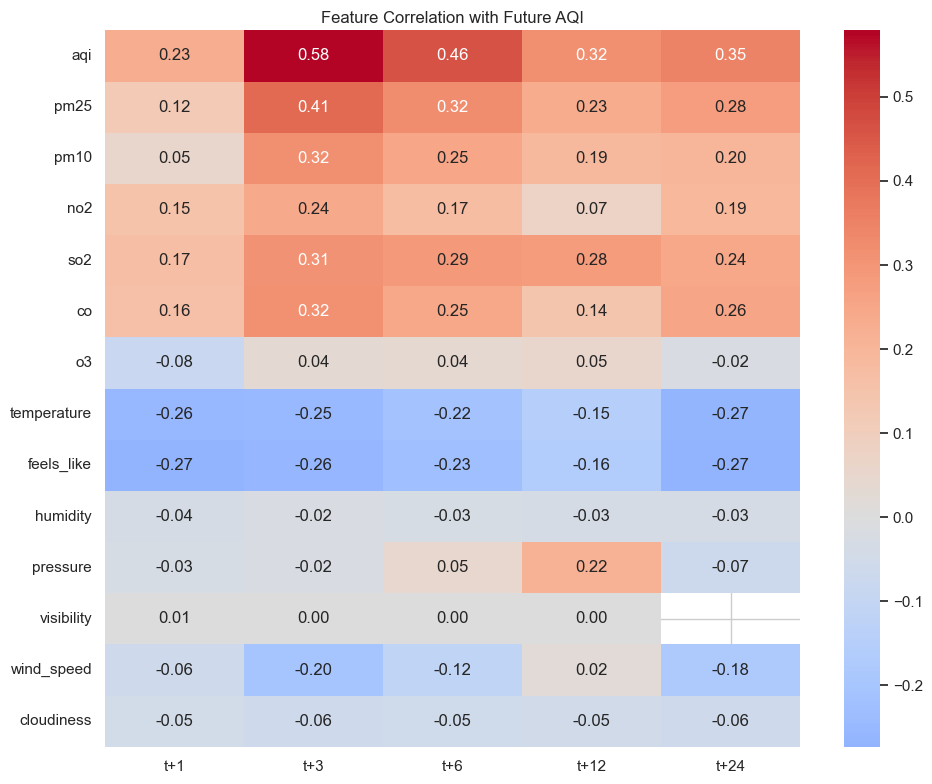

In [8]:
horizons = [1, 3, 6, 12, 24]
future_corr = {}

for h in horizons:
    future_col = f"aqi_future_{h}"
    df[future_col] = df[TARGET_COL].shift(-h)
    for col in numeric_features:
        c = df[[col, future_col]].corr().iloc[0, 1]
        if not pd.isna(c):
            future_corr[f"{col}_vs_t+{h}"] = round(float(c), 4)

# Build matrix
future_matrix = pd.DataFrame(index=numeric_features, columns=[f"t+{h}" for h in horizons])
for col in numeric_features:
    for h in horizons:
        future_matrix.loc[col, f"t+{h}"] = future_corr.get(f"{col}_vs_t+{h}", np.nan)
future_matrix = future_matrix.astype(float)

fr_stats["future_target_correlation"] = future_matrix.to_dict()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(future_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature Correlation with Future AQI")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "future_target_correlation.png", dpi=110, bbox_inches="tight")
plt.show()

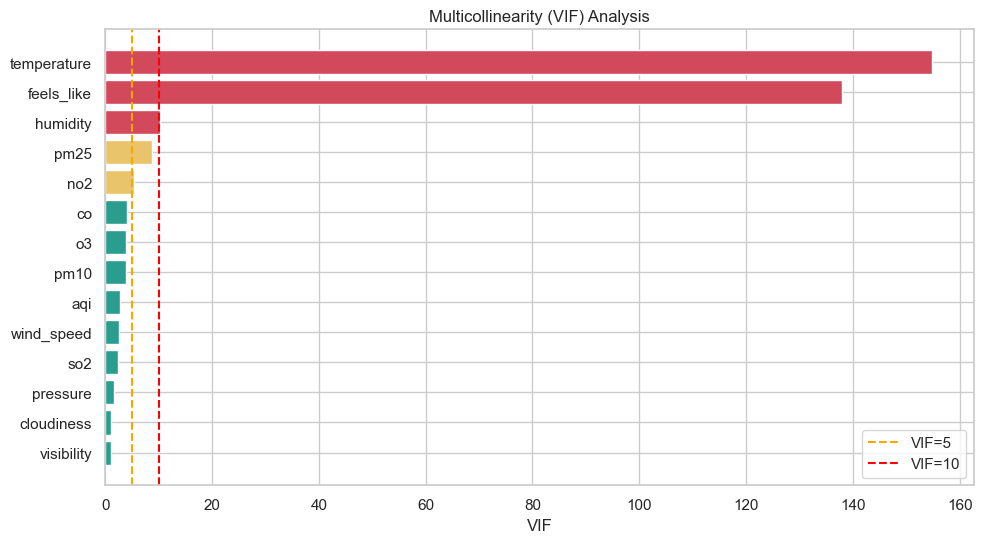

In [9]:
# Top features for VIF (exclude lag/roll for base features)
base_features = [c for c in numeric_features if "_lag_" not in c and "_roll" not in c and "_future_" not in c]
base_features = [c for c in base_features if c in df.columns]

vif_df = df[base_features].dropna()
X_vif = vif_df.copy()
X_vif["const"] = 1

vif_results = []
for i, col in enumerate(base_features):
    try:
        v = variance_inflation_factor(X_vif.values, i)
        vif_results.append({"feature": col, "vif": round(float(v), 2)})
    except:
        vif_results.append({"feature": col, "vif": np.inf})

vif_df_out = pd.DataFrame(vif_results).sort_values("vif", ascending=False)

fr_stats["vif_analysis"] = {
    "features_tested": len(vif_results),
    "vif_gt_10": vif_df_out[vif_df_out["vif"] > 10]["feature"].tolist(),
    "vif_gt_5": vif_df_out[vif_df_out["vif"] > 5]["feature"].tolist(),
    "scores": vif_df_out.to_dict(orient="records"),
}

fig, ax = plt.subplots(figsize=(10, max(4, len(vif_results) * 0.4)))
colors = ["#d1495b" if v > 10 else "#e9c46a" if v > 5 else "#2a9d8f" for v in vif_df_out["vif"]]
ax.barh(vif_df_out["feature"][::-1], vif_df_out["vif"][::-1], color=colors[::-1])
ax.axvline(x=5, color="orange", linestyle="--", label="VIF=5")
ax.axvline(x=10, color="red", linestyle="--", label="VIF=10")
ax.set_xlabel("VIF")
ax.set_title("Multicollinearity (VIF) Analysis")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "vif_analysis.png", dpi=110, bbox_inches="tight")
plt.show()

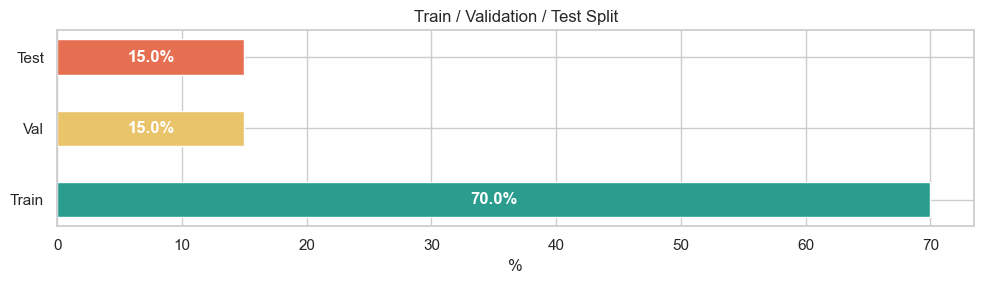

In [10]:
n = len(df)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

split_info = {
    "train": {"n": len(train_df), "pct": round(len(train_df)/n*100, 1),
              "start": str(train_df[TIME_COL].min()), "end": str(train_df[TIME_COL].max())},
    "val": {"n": len(val_df), "pct": round(len(val_df)/n*100, 1),
            "start": str(val_df[TIME_COL].min()), "end": str(val_df[TIME_COL].max())},
    "test": {"n": len(test_df), "pct": round(len(test_df)/n*100, 1),
             "start": str(test_df[TIME_COL].min()), "end": str(test_df[TIME_COL].max())},
    "overlap": {
        "train_val": bool(train_df[TIME_COL].max() >= val_df[TIME_COL].min()),
        "val_test": bool(val_df[TIME_COL].max() >= test_df[TIME_COL].min()),
    }
}
fr_stats["train_val_test_split"] = split_info

fig, ax = plt.subplots(figsize=(10, 3))
labels = ["Train", "Val", "Test"]
sizes = [split_info["train"]["pct"], split_info["val"]["pct"], split_info["test"]["pct"]]
colors = ["#2a9d8f", "#e9c46a", "#e76f51"]
ax.barh([0, 1, 2], sizes, color=colors, height=0.5)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(labels)
ax.set_xlabel("%")
ax.set_title("Train / Validation / Test Split")
for i, s in enumerate(sizes):
    ax.text(s/2, i, f"{s:.1f}%", ha="center", va="center", color="white", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "train_val_test_split.png", dpi=110, bbox_inches="tight")
plt.show()

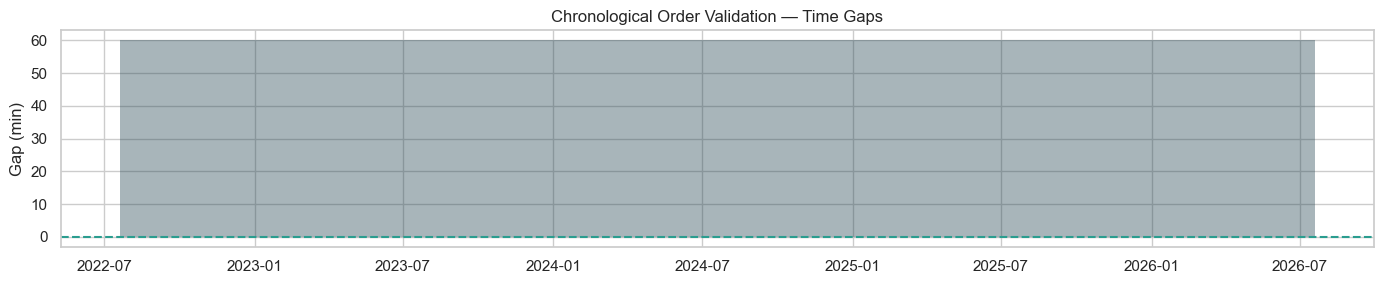

Chronological: True | Negative diffs: 0 | Duplicates: 70032


In [11]:
is_chrono = df[TIME_COL].is_monotonic_increasing
diffs = df[TIME_COL].diff().dropna()
neg_diffs = int((diffs < pd.Timedelta(0)).sum())
dupes = int(df[TIME_COL].duplicated().sum())

chrono = {
    "strictly_chronological": bool(is_chrono),
    "negative_diffs": neg_diffs,
    "duplicate_timestamps": dupes,
    "expected_interval_min": int(diffs.mode()[0].total_seconds()/60) if len(diffs) > 0 else None,
}
fr_stats["chronological_validation"] = chrono

fig, ax = plt.subplots(figsize=(14, 3))
gap_min = diffs.dt.total_seconds() / 60
ax.plot(df[TIME_COL].iloc[1:], gap_min, color="#264653", alpha=0.4, linewidth=0.3)
ax.axhline(y=gap_min.mode()[0] if len(gap_min) > 0 else 60, color="#2a9d8f", linestyle="--")
ax.set_title("Chronological Order Validation — Time Gaps")
ax.set_ylabel("Gap (min)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "chronological_validation.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"Chronological: {is_chrono} | Negative diffs: {neg_diffs} | Duplicates: {dupes}")

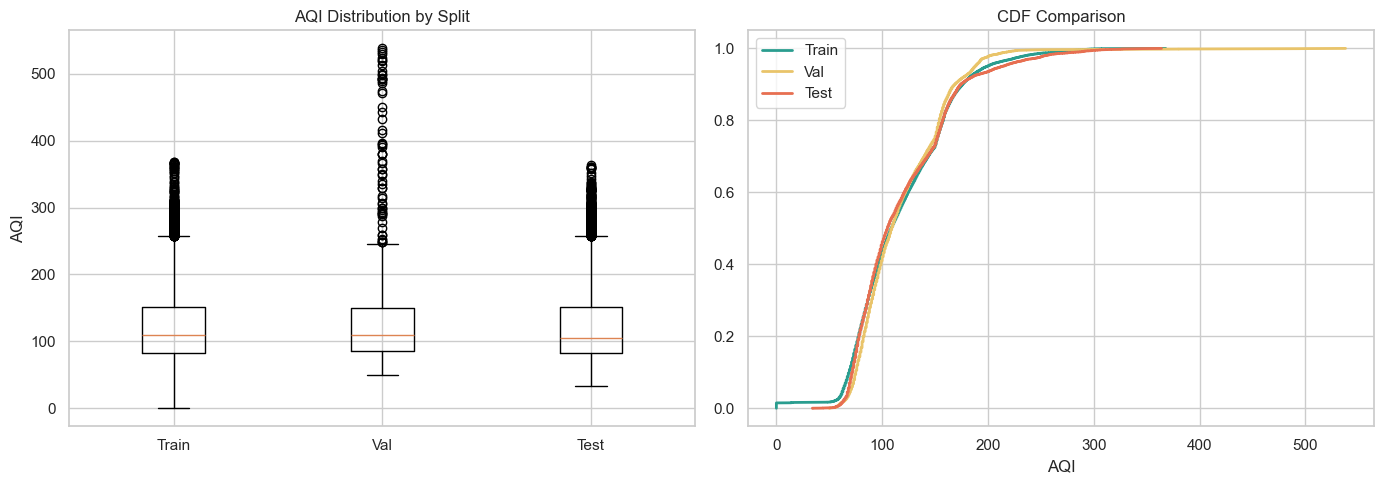

In [12]:
train_y = train_df[TARGET_COL].dropna()
val_y = val_df[TARGET_COL].dropna()
test_y = test_df[TARGET_COL].dropna()

dist_stats = {
    "overall": {"mean": round(float(df[TARGET_COL].mean()), 2), "std": round(float(df[TARGET_COL].std()), 2)},
    "train": {"mean": round(float(train_y.mean()), 2), "std": round(float(train_y.std()), 2)},
    "val": {"mean": round(float(val_y.mean()), 2), "std": round(float(val_y.std()), 2)},
    "test": {"mean": round(float(test_y.mean()), 2), "std": round(float(test_y.std()), 2)},
}

# KS tests
ks_tv = stats.ks_2samp(train_y, val_y)
ks_vt = stats.ks_2samp(val_y, test_y)
ks_tt = stats.ks_2samp(train_y, test_y)

dist_stats["ks_tests"] = {
    "train_val": {"stat": round(ks_tv.statistic, 4), "p": round(ks_tv.pvalue, 4)},
    "val_test": {"stat": round(ks_vt.statistic, 4), "p": round(ks_vt.pvalue, 4)},
    "train_test": {"stat": round(ks_tt.statistic, 4), "p": round(ks_tt.pvalue, 4)},
}
fr_stats["target_distribution"] = dist_stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot([train_y, val_y, test_y], labels=["Train", "Val", "Test"])
axes[0].set_title("AQI Distribution by Split")
axes[0].set_ylabel("AQI")

for data, label, color in zip([train_y, val_y, test_y], ["Train", "Val", "Test"], ["#2a9d8f", "#e9c46a", "#e76f51"]):
    sorted_d = np.sort(data)
    axes[1].plot(sorted_d, np.arange(1, len(sorted_d)+1)/len(sorted_d), label=label, color=color, linewidth=2)
axes[1].set_title("CDF Comparison")
axes[1].set_xlabel("AQI")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "target_distribution_analysis.png", dpi=110, bbox_inches="tight")
plt.show()

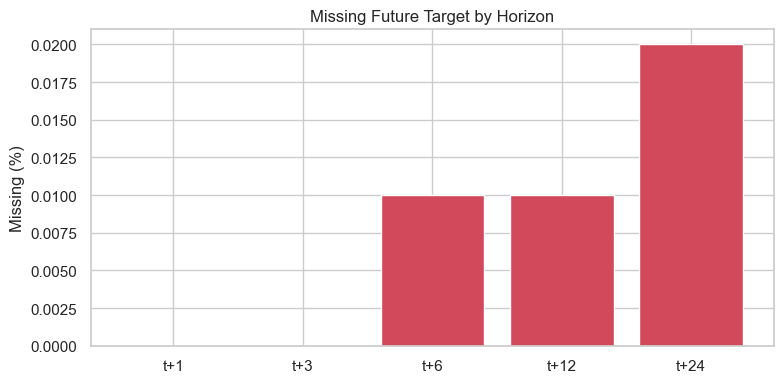

In [13]:
missing_future = {}
for h in [1, 3, 6, 12, 24]:
    col = f"aqi_future_{h}"
    if col in df.columns:
        mc = df[col].isna().sum()
        missing_future[f"t+{h}"] = {
            "missing": int(mc),
            "missing_pct": round(mc/len(df)*100, 2),
            "usable": int(len(df) - mc),
        }
fr_stats["missing_future_target"] = missing_future

fig, ax = plt.subplots(figsize=(8, 4))
horizons = list(missing_future.keys())
pcts = [missing_future[h]["missing_pct"] for h in horizons]
ax.bar(horizons, pcts, color="#d1495b")
ax.set_ylabel("Missing (%)")
ax.set_title("Missing Future Target by Horizon")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "missing_future_target.png", dpi=110, bbox_inches="tight")
plt.show()

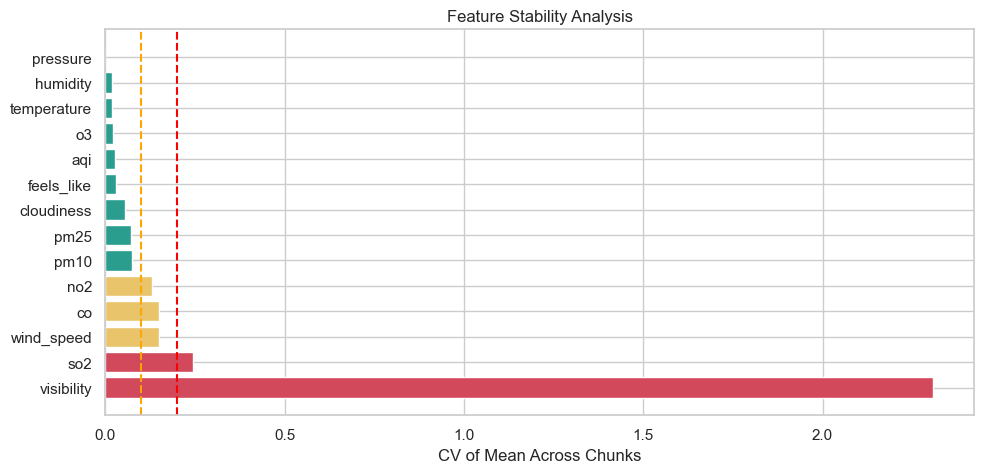

In [14]:
n_chunks = 4
chunk_size = len(df) // n_chunks
chunk_means = {}

for i in range(n_chunks):
    chunk = df.iloc[i*chunk_size : (i+1)*chunk_size if i < n_chunks-1 else len(df)]
    chunk_means[f"chunk_{i+1}"] = {col: round(float(chunk[col].mean()), 4) for col in numeric_features if col in chunk.columns}

stability = {}
for col in numeric_features:
    means = [chunk_means[c].get(col, np.nan) for c in chunk_means]
    means = [m for m in means if not pd.isna(m)]
    if means and np.mean(means) != 0:
        stability[col] = round(float(np.std(means) / abs(np.mean(means))), 4)

fr_stats["feature_stability"] = {
    "cv_by_feature": stability,
    "unstable_cv_gt_0_2": [k for k, v in stability.items() if v > 0.2],
}

fig, ax = plt.subplots(figsize=(10, max(4, len(stability)*0.35)))
sorted_s = dict(sorted(stability.items(), key=lambda x: x[1], reverse=True))
colors = ["#d1495b" if v > 0.2 else "#e9c46a" if v > 0.1 else "#2a9d8f" for v in sorted_s.values()]
ax.barh(list(sorted_s.keys()), list(sorted_s.values()), color=colors)
ax.axvline(x=0.1, color="orange", linestyle="--")
ax.axvline(x=0.2, color="red", linestyle="--")
ax.set_xlabel("CV of Mean Across Chunks")
ax.set_title("Feature Stability Analysis")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_stability.png", dpi=110, bbox_inches="tight")
plt.show()

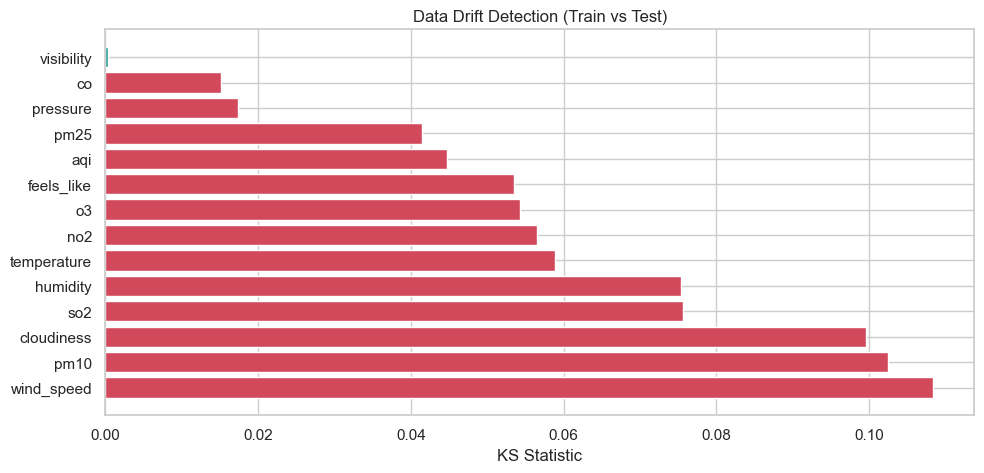

Drifted: 13/14 features


In [15]:
drift = {}
for col in numeric_features:
    t = train_df[col].dropna()
    te = test_df[col].dropna()
    if len(t) > 0 and len(te) > 0:
        ks, p = stats.ks_2samp(t, te)
        drift[col] = {"ks": round(float(ks), 4), "p": round(float(p), 4), "drift": p < 0.05}

drifted = [k for k, v in drift.items() if v["drift"]]
fr_stats["data_drift"] = {
    "tested": len(drift),
    "drifted_count": len(drifted),
    "drifted_features": drifted,
    "details": drift,
}

fig, ax = plt.subplots(figsize=(10, max(4, len(drift)*0.35)))
sorted_d = dict(sorted(drift.items(), key=lambda x: x[1]["ks"], reverse=True))
colors = ["#d1495b" if drift[k]["drift"] else "#2a9d8f" for k in sorted_d.keys()]
ax.barh(list(sorted_d.keys()), [v["ks"] for v in sorted_d.values()], color=colors)
ax.set_xlabel("KS Statistic")
ax.set_title("Data Drift Detection (Train vs Test)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "data_drift_detection.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"Drifted: {len(drifted)}/{len(drift)} features")

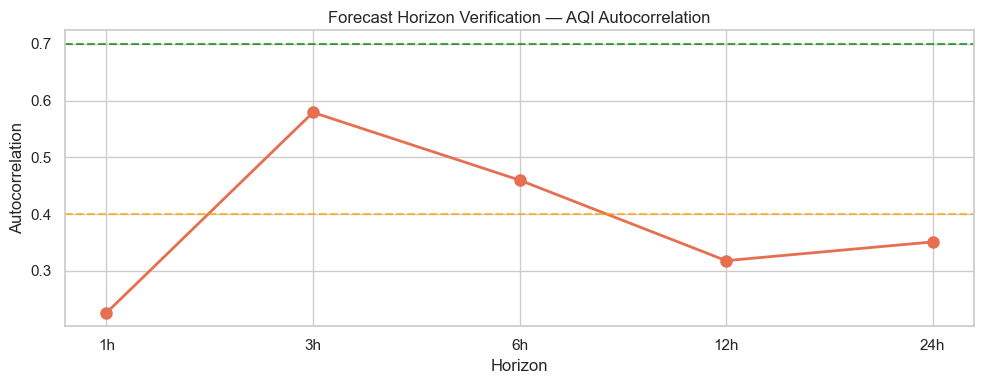

In [16]:
horizon_analysis = {}
for h in [1, 3, 6, 12, 24, 48, 72]:
    col = f"aqi_future_{h}"
    if col in df.columns:
        ac = df[[TARGET_COL, col]].corr().iloc[0, 1]
        horizon_analysis[f"{h}h"] = {
            "autocorr": round(float(ac), 4) if not pd.isna(ac) else None,
            "predictability": "High" if ac and ac > 0.7 else "Medium" if ac and ac > 0.4 else "Low",
        }

fr_stats["forecast_horizon_verification"] = horizon_analysis

fig, ax = plt.subplots(figsize=(10, 4))
hs = [k for k in horizon_analysis.keys()]
acs = [horizon_analysis[h]["autocorr"] for h in hs if horizon_analysis[h]["autocorr"] is not None]
valid_hs = [h for h in hs if horizon_analysis[h]["autocorr"] is not None]
ax.plot(valid_hs, acs, marker="o", color="#e76f51", linewidth=2, markersize=8)
ax.axhline(y=0.7, color="green", linestyle="--", alpha=0.7)
ax.axhline(y=0.4, color="orange", linestyle="--", alpha=0.7)
ax.set_title("Forecast Horizon Verification — AQI Autocorrelation")
ax.set_xlabel("Horizon")
ax.set_ylabel("Autocorrelation")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "forecast_horizon_verification.png", dpi=110, bbox_inches="tight")
plt.show()

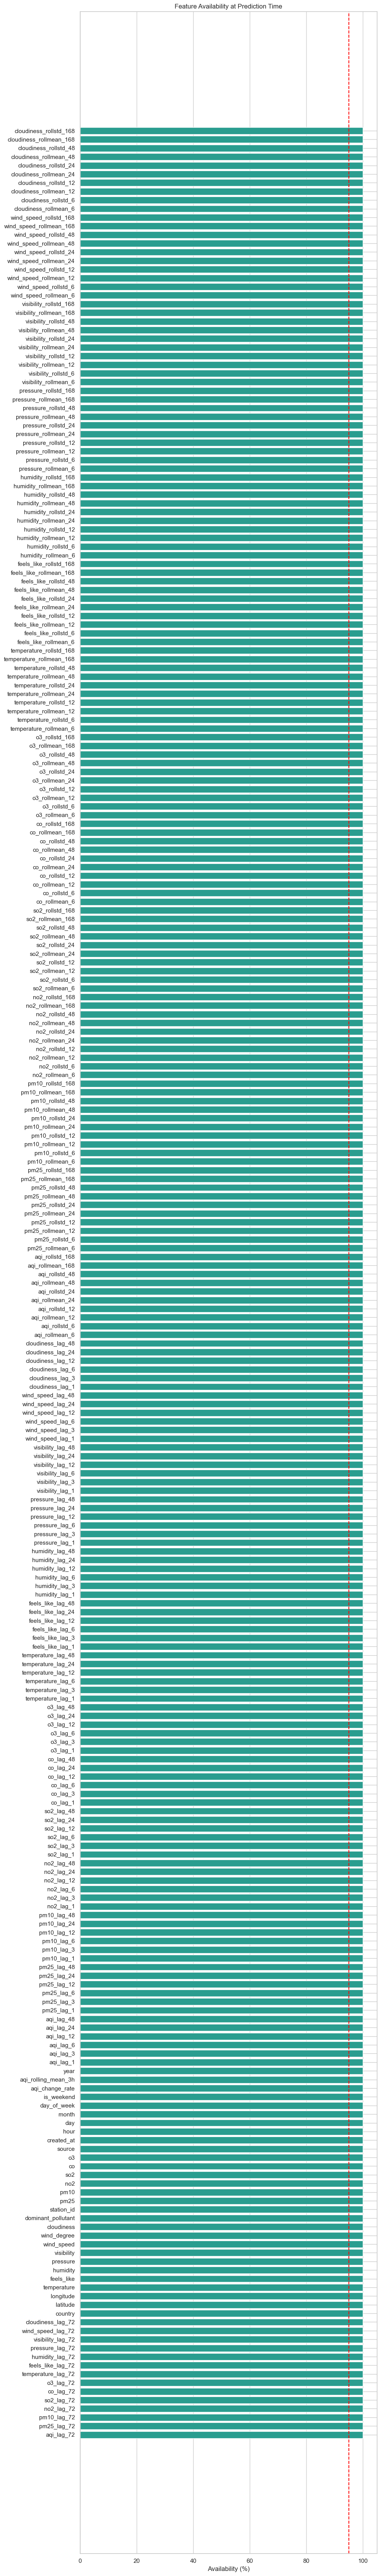

In [17]:
# Features usable at prediction time (no future info)
future_cols = [c for c in df.columns if "_future_" in c or "_lead_" in c]
available = [c for c in df.columns if c not in future_cols + [TARGET_COL, TIME_COL, CITY_COL]]

avail_pct = {}
for col in available:
    if col in df.columns:
        avail_pct[col] = round(float((~df[col].isna()).mean() * 100), 1)

low = {k: v for k, v in avail_pct.items() if v < 95}
fr_stats["feature_availability"] = {
    "total": len(available),
    "avg_availability": round(float(np.mean(list(avail_pct.values()))), 1),
    "below_95pct": low,
}

fig, ax = plt.subplots(figsize=(10, max(4, len(avail_pct)*0.25)))
sorted_a = dict(sorted(avail_pct.items(), key=lambda x: x[1]))
colors = ["#d1495b" if v < 95 else "#2a9d8f" for v in sorted_a.values()]
ax.barh(list(sorted_a.keys()), list(sorted_a.values()), color=colors)
ax.axvline(x=95, color="red", linestyle="--")
ax.set_xlabel("Availability (%)")
ax.set_title("Feature Availability at Prediction Time")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_availability.png", dpi=110, bbox_inches="tight")
plt.show()

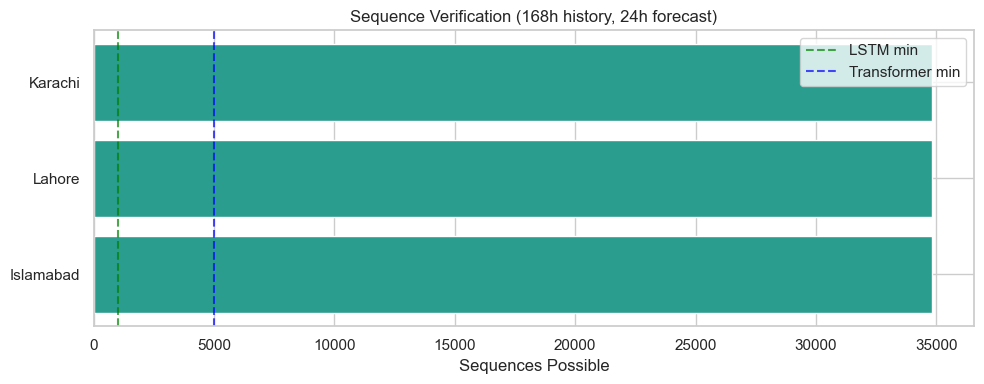

Total sequences: 104863 | LSTM ready: True | Transformer ready: True


In [18]:
city_seq = {}
for city in df[CITY_COL].dropna().unique():
    cd = df[df[CITY_COL] == city]
    possible = max(0, len(cd) - SEQUENCE_LENGTH - FORECAST_HORIZON + 1)
    city_seq[city] = {
        "records": len(cd),
        "sequences": possible,
        "lstm_ready": possible > 100,
        "transformer_ready": possible > 5000,
    }

total_seq = max(0, len(df) - SEQUENCE_LENGTH - FORECAST_HORIZON + 1)
fr_stats["sequence_length_verification"] = {
    "sequence_length": SEQUENCE_LENGTH,
    "forecast_horizon": FORECAST_HORIZON,
    "total_sequences": total_seq,
    "per_city": city_seq,
    "overall_lstm_ready": total_seq > 1000,
    "overall_transformer_ready": total_seq > 5000,
}

fig, ax = plt.subplots(figsize=(10, max(4, len(city_seq)*0.4)))
cities = list(city_seq.keys())
seqs = [city_seq[c]["sequences"] for c in cities]
colors = ["#2a9d8f" if v > 5000 else "#e9c46a" if v > 1000 else "#d1495b" for v in seqs]
ax.barh(cities, seqs, color=colors)
ax.axvline(x=1000, color="green", linestyle="--", alpha=0.7, label="LSTM min")
ax.axvline(x=5000, color="blue", linestyle="--", alpha=0.7, label="Transformer min")
ax.set_xlabel("Sequences Possible")
ax.set_title(f"Sequence Verification ({SEQUENCE_LENGTH}h history, {FORECAST_HORIZON}h forecast)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "sequence_length_verification.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"Total sequences: {total_seq} | LSTM ready: {total_seq > 1000} | Transformer ready: {total_seq > 5000}")

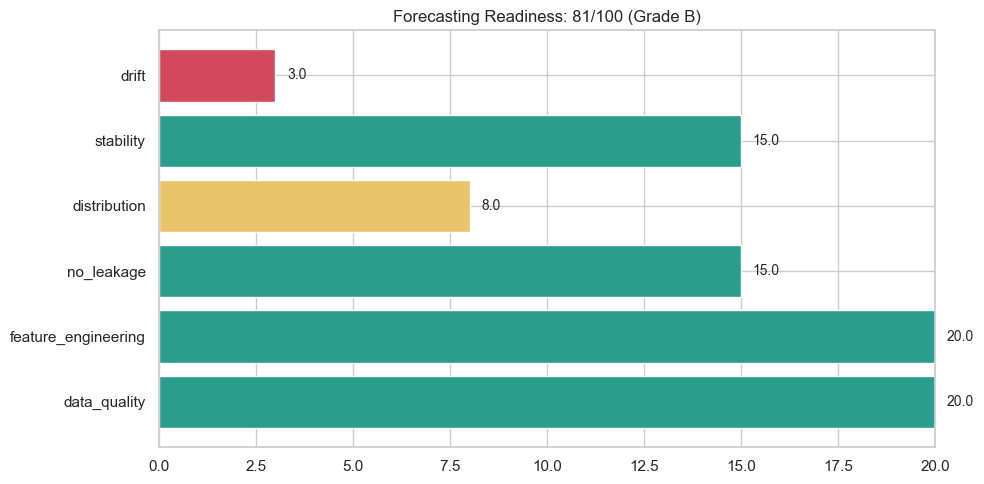

=== READINESS REPORT ===
Score: 81/100 | Grade: B
  data_quality: 20.0
  feature_engineering: 20.0
  no_leakage: 15.0
  distribution: 8.0
  stability: 15.0
  drift: 3.0
  → Address data drift between train/test


In [19]:
scores = {}
scores["data_quality"] = 20 if chrono.get("strictly_chronological") else 10
scores["feature_engineering"] = min(20, len(lag_sorted)/2 + len(roll_sorted)/4)
scores["no_leakage"] = max(0, 20 - fr_stats["target_leakage_detection"]["risk_score"] * 5)
scores["distribution"] = 15 if dist_stats["ks_tests"]["train_test"]["p"] > 0.05 else 8
scores["stability"] = 15 if len(fr_stats["feature_stability"]["unstable_cv_gt_0_2"]) < 3 else 8
scores["drift"] = 15 if len(drifted) == 0 else 8 if len(drifted) < 3 else 3

total = sum(scores.values())
grade = "A" if total >= 85 else "B" if total >= 70 else "C" if total >= 50 else "D"

summary = {
    "score": round(total, 1),
    "max": 100,
    "grade": grade,
    "components": {k: round(v, 1) for k, v in scores.items()},
    "recommendations": [],
}

if scores["data_quality"] < 15:
    summary["recommendations"].append("Fix chronological ordering issues")
if scores["no_leakage"] < 10:
    summary["recommendations"].append("Remove target leakage features")
if scores["drift"] < 10:
    summary["recommendations"].append("Address data drift between train/test")
if scores["stability"] < 10:
    summary["recommendations"].append("Investigate unstable features")
if not summary["recommendations"]:
    summary["recommendations"].append("Dataset is forecast-ready. Proceed with modeling.")

fr_stats["forecasting_readiness_summary"] = summary

fig, ax = plt.subplots(figsize=(10, 5))
comps = list(scores.keys())
vals = list(scores.values())
colors = ["#2a9d8f" if v >= 12 else "#e9c46a" if v >= 8 else "#d1495b" for v in vals]
bars = ax.barh(comps, vals, color=colors)
ax.set_xlim(0, 20)
ax.set_title(f"Forecasting Readiness: {total}/100 (Grade {grade})")
for bar, v in zip(bars, vals):
    ax.text(v + 0.3, bar.get_y() + bar.get_height()/2, f"{v:.1f}", va="center", fontsize=10)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "forecasting_readiness_summary.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"=== READINESS REPORT ===")
print(f"Score: {total}/100 | Grade: {grade}")
for k, v in scores.items():
    print(f"  {k}: {v:.1f}")
for r in summary["recommendations"]:
    print(f"  → {r}")

In [20]:
with STATS_PATH.open("w", encoding="utf-8") as f:
    json.dump(
        {
            "generated_at": datetime.now(timezone.utc).isoformat(),
            "dataset_path": str(DATA_PATH),
            "shape": {"rows": df.shape[0], "columns": df.shape[1]},
            "config": {"horizon": FORECAST_HORIZON, "sequence": SEQUENCE_LENGTH},
            **fr_stats,
        },
        f,
        indent=2,
        default=str,
    )
print(f"Saved -> {STATS_PATH}")

Saved -> ..\reports\eda_forecast_ready\forecast_readiness_stats.json
